# SVM AND DECISION TREES CLASSIFICATION , AND FULL EVALUATION

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 


In [3]:
from sklearn import datasets

x = datasets.load_iris()
x

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [4]:
x['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

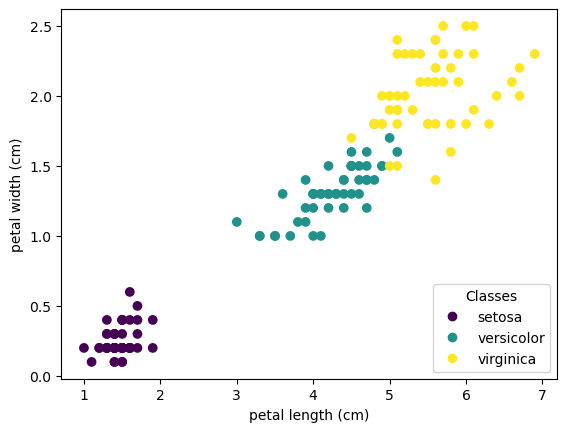

In [5]:
import matplotlib.pyplot as plt

_, ax = plt.subplots()
scatter = ax.scatter(x.data[:,2],x.data[:,3], c=x.target)
ax.set(xlabel=x.feature_names[2], ylabel=x.feature_names[3])
_ = ax.legend(
    scatter.legend_elements()[0], x.target_names, loc="lower right", title="Classes"
)


In [6]:
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import DecisionBoundaryDisplay 
from sklearn.model_selection import train_test_split

In [84]:
x.data.size , x.target.size

(600, 150)

In [7]:
x_train,x_test,y_train,y_test = train_test_split(x.data,x.target,test_size = 0.2)
x_train.size

480

In [8]:
y_train.size

120

In [9]:
log_reg = LogisticRegression()
log_reg.fit(x_train[:,2:4],y_train)

LogisticRegression()

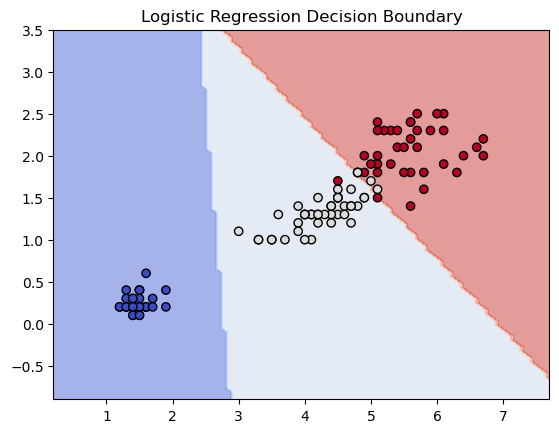

In [15]:
from sklearn.inspection import DecisionBoundaryDisplay
display = DecisionBoundaryDisplay.from_estimator(
    log_reg, 
    x_train[:,2:4], 
    response_method="predict", # Uses 0 or 1 for sharp boundaries
    cmap="coolwarm",           # Color scheme
    alpha=0.5                  # Transparency of the background
)

# 4. Scatter the original data points on top so you can see how they fit
display.ax_.scatter(x_train[:, 2], x_train[:, 3],c = y_train, edgecolor="k", cmap="coolwarm")
plt.title("Logistic Regression Decision Boundary")
plt.show()

In [28]:
from sklearn.svm import LinearSVC
svm_clf = LinearSVC(C=8,loss ='hinge')
svm_clf.fit(x_train[:,2:4],y_train)

d:\ANACONDA\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(C=8, loss='hinge')

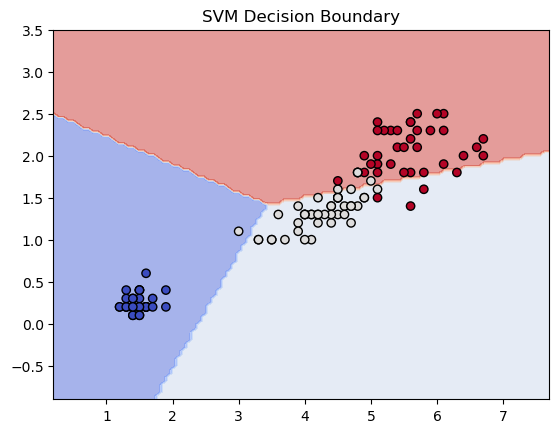

In [29]:
display2 = DecisionBoundaryDisplay.from_estimator(
    svm_clf,
    x_train[:,2:4],
    response_method='predict',
    cmap = 'coolwarm',
    alpha =0.5
)

display2.ax_.scatter(x_train[:, 2], x_train[:, 3],c = y_train, edgecolor="k", cmap="coolwarm")
plt.title("SVM Decision Boundary")
plt.show()

In [38]:
rbf_svm_clf = SVC(kernel='rbf',gamma=0.1,C=0.1)
rbf_svm_clf.fit(x_train[:,2:4],y_train)

SVC(C=0.1, gamma=0.1)

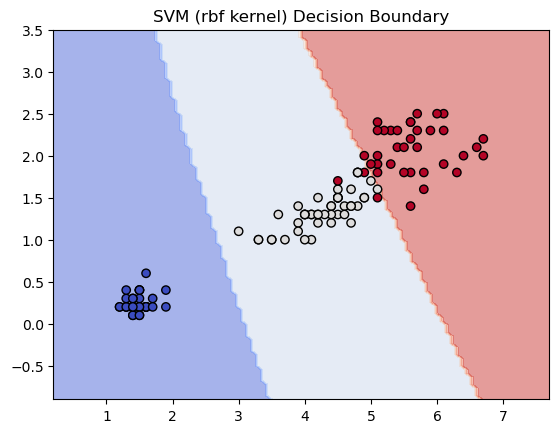

In [39]:
display3 = DecisionBoundaryDisplay.from_estimator(
    rbf_svm_clf,
    x_train[:,2:4],
    response_method='predict',
    cmap = 'coolwarm',
    alpha =0.5
)

display3.ax_.scatter(x_train[:, 2], x_train[:, 3],c = y_train, edgecolor="k", cmap="coolwarm")
plt.title("SVM (rbf kernel) Decision Boundary")
plt.show()

In [54]:
tree_clf = DecisionTreeClassifier(max_depth=2)
tree_clf.fit(x_train[:,2:4],y_train)

DecisionTreeClassifier(max_depth=2)

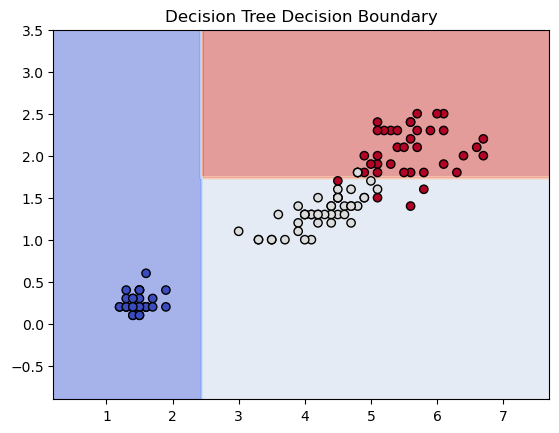

In [55]:
display4 = DecisionBoundaryDisplay.from_estimator(
    tree_clf,
    x_train[:,2:4],
    response_method='predict',
    cmap = 'coolwarm',
    alpha =0.5
)

display4.ax_.scatter(x_train[:, 2], x_train[:, 3],c = y_train, edgecolor="k", cmap="coolwarm")
plt.title("Decision Tree Decision Boundary")
plt.show()

comparison of each model (Logistic regression , SVM(linear , rbf) , Decision Tree)  

In [60]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from scipy.special import softmax

X_test_subset = x_test[:, 2:4]

classifiers = {
    "Logistic Regression": log_reg,
    "Linear SVC": svm_clf,
    "RBF SVC": rbf_svm_clf,
    "Decision Tree": tree_clf
}

metrics_data = []

for name, clf in classifiers.items():
    y_pred = clf.predict(X_test_subset)
    
    if hasattr(clf, "decision_function"):
        raw_scores = clf.decision_function(X_test_subset)
        y_scores = softmax(raw_scores, axis=1)
    else:
        y_scores = clf.predict_proba(X_test_subset) 
        
    metrics_data.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred, average='weighted'),
        "ROC-AUC": roc_auc_score(y_test, y_scores, multi_class='ovr', average='weighted')
    })

results_df = pd.DataFrame(metrics_data)

print(results_df.to_string(index=False))

              Model  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression   0.971429 0.966667  0.967155  1.00000
         Linear SVC   0.950000 0.933333  0.934762  0.99057
            RBF SVC   0.950000 0.933333  0.934762  1.00000
      Decision Tree   0.971429 0.966667  0.967155  0.99057
